# Improvement Model Proposal Phase 1

#### Authors : Tayyab Waseem & Abdul Hadi

</n>

## Strategic Integration of Shared Low-Rank Adaptation and Private Sparse Personalized Identities in Federated Learning




The integration of foundation models into federated learning (FL) systems represents a watershed moment in decentralized artificial intelligence. As these models scale to hundreds of billions of parameters, the traditional FL paradigm—where full model weights are synchronized across clients—has become increasingly untenable due to the prohibitive communication and computational burdens placed on edge devices. In response, the academic community has pivoted toward Parameter-Efficient Fine-Tuning (PEFT) techniques, with Low-Rank Adaptation (LoRA) emerging as the dominant standard. LoRA facilitates model adaptation by freezing the pretrained backbone and optimizing only low-rank matrices, thereby drastically reducing the volume of updates. However, the fundamental challenge of data heterogeneity in non-IID environments remains unresolved, as global aggregation often leads to a "one-size-fits-none" model that fails to satisfy individual client tasks.

The proposed research idea, combining a globally shared, aggregated LoRA with a strictly private, LTH-sparse local adapter, seeks to resolve this tension by decoupling general collaborative knowledge from a client’s "personalized identity".

Recent studies have demonstrated that PEFT is uniquely suited for the federated setting not only for its efficiency but also for its ability to maintain "model fidelity" to the pretrained distribution. By restricting updates to a small subspace, LoRA naturally acts as a regularizer, preventing the massive "client drift" that typically occurs when full parameters are updated on small, biased local datasets. This regularization is a critical precursor to the proposed idea of a "sparse personalized identity," as it ensures that the local adapter has a stable, generalizable foundation from which to carve out its unique functional sub-network.

### Comparative Analysis of Dual-Adapter Architectures

The first component of the proposed idea involves a dual-adapter structure where one adapter is shared and the other is strictly private. This "decoupled" paradigm has seen significant activity between 2024 and early 2026. The conceptual shift here is to move from "partial model sharing" to "additive decomposition of knowledge".

The second critical component of the proposed idea is the application of the Lottery Ticket Hypothesis (LTH) or weight masking to the local adapter. The LTH posits that dense networks contain sparse subnetworks that can achieve the same or better performance when trained in isolation. In the context of the proposed idea, this is not merely an efficiency measure but a tool for creating a "personalized identity."

The primary distinction between FedDLP and the proposed idea lies in the nature and purpose of the sparsity. In FedDLP, pruning is a dynamic optimization step to enhance computational scalability and memory efficiency for a "larger" local adapter. In the proposed idea, the sparsity is a "Lottery-Ticket-style" identification of a sub-network that serves as a task-specific identity. Furthermore, FedDLP's methodology is grounded in SVD-based importance scoring rather than the binary magnitude-based or gradient-based masking typically associated with LTH-style "winning tickets".

### Research Proposal

This project proposes a novel "Dual-Adapter" system designed to personalize large AI models, such as Llama or CLIP, for individual users while ensuring absolute data privacy. In standard federated learning, all users collaborate to build a single model, which often fails to perform well for users with unique or specific needs. Our approach introduces a two-part solution: a "Global Shared Adapter" that learns general patterns from the entire user base, and a "Private Sparse Identity" adapter that stays strictly on the individual’s device and is never shared with a central server. This private adapter uses a technique called the Lottery Ticket Hypothesis to "mask out" 90% or more of its connections, identifying and keeping only the few essential links that capture the user's specific habits and tasks. By creating this sparse, personalized fingerprint at the architectural level, we achieve a model that is both highly accurate for the individual and light enough to run on basic hardware, all while providing a mathematically superior layer of privacy that hides the user's personal task patterns from the rest of the network.


**Goal: Our zero-shot Dual-Module architecture should achieve higher personalization accuracy than standard FedAvg even after it undergoes K-step local fine-tuning. Crucially, it achieves this without adding a single byte of communication overhead compared to the standard FedAvg baseline, because the dense global consensus is identical in size, while the sparse personalized identity never leaves the edge device.**

### Section 1: BASELINE WORK

In [1]:
!pip install -q peft datasets evaluate accelerate

import textwrap
import math
import torch
from IPython.display import display, HTML
import html
import numpy as np
from datasets import load_dataset
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding
from peft import LoraConfig, get_peft_model, TaskType
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from torch.nn.utils import clip_grad_norm_
import torch.nn.functional as F
from torch.optim import AdamW
from tqdm import tqdm
from copy import deepcopy
from transformers import AutoTokenizer

import warnings
import logging

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.0 MB/s eta 0:00:00
Device: cuda


In [2]:
CONFIG = {
    'num_clients': 4,
    'class_names': ['World', 'Sports', 'Business', 'Sci/Tech'],
    'dominant_ratio': 0.80,
    'n_train': 2000, # 2000
    'n_test': 500, # 500
    'n_global_test': 400, # 400
    'model_name': 'distilbert-base-uncased',
    'num_labels': 4,
    'max_length': 128,
    'lora_r': 8,
    'lora_alpha': 16,
    'lora_dropout': 0.1,
    'target_modules': ['q_lin', 'v_lin'],
    'num_rounds': 30, # 30
    'local_epochs': 2, # 2 standard in FL + PEFT papers 
    'batch_size': 32,
    'lr': 1e-4,
    'weight_decay': 0.01,
    'device': device,
    'seed': SEED,

    'bits_per_param': 32,  # float32
    'num_local_epochs': 5
}

In [3]:
CONFIG['personalization_steps'] = CONFIG['n_train'] // CONFIG['batch_size']

In [4]:
# Suppressing WARNINGS - VERY IMPORTANT 

warnings.filterwarnings("ignore", message=".*UNEXPECTED.*")
warnings.filterwarnings("ignore", message=".*MISSING.*")

In [5]:
dataset = load_dataset("ag_news")
print(f"Train: {len(dataset['train']):,} | Test: {len(dataset['test']):,}")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Train: 120,000 | Test: 7,600


In [6]:
tokenizer = AutoTokenizer.from_pretrained(CONFIG['model_name'])

def tokenize_fn(examples):
    return tokenizer(examples['text'], truncation=True, max_length=CONFIG['max_length'])

tokenized = dataset.map(tokenize_fn, batched=True, remove_columns=['text'])
tokenized = tokenized.rename_column('label', 'labels')
tokenized.set_format('torch')

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/120000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

In [7]:
def create_noniid_splits(split, num_clients, n_samples, dominant_ratio=0.8):
    labels = np.array(split['labels'])
    class_idx = {c: np.where(labels == c)[0] for c in range(num_clients)}
    client_indices = []
    rng = np.random.default_rng(CONFIG['seed'])
    for cid in range(num_clients):
        n_dom = int(n_samples * dominant_ratio)
        n_oth = (n_samples - n_dom) // (num_clients - 1)
        dom = rng.choice(class_idx[cid], min(n_dom, len(class_idx[cid])), replace=False)
        oth = []
        for c in range(num_clients):
            if c != cid:
                oth.extend(rng.choice(class_idx[c], min(n_oth, len(class_idx[c])), replace=False).tolist())
        idx = np.concatenate([dom, np.array(oth)])
        rng.shuffle(idx)
        client_indices.append(idx[:n_samples])
    return client_indices

train_idx = create_noniid_splits(tokenized['train'], CONFIG['num_clients'], CONFIG['n_train'])
test_idx  = create_noniid_splits(tokenized['test'],  CONFIG['num_clients'], CONFIG['n_test'])

test_labels = np.array(tokenized['test']['labels'])
global_test_idx = np.concatenate([
    np.where(test_labels == c)[0][:CONFIG['n_global_test']] for c in range(4)
])

print("Non-IID partitioning completed.")
print(f"Global test set size: {len(global_test_idx)} samples (balanced)")

Non-IID partitioning completed.
Global test set size: 1600 samples (balanced)


In [8]:
# base_model = AutoModelForSequenceClassification.from_pretrained(
#     CONFIG['model_name'], num_labels=CONFIG['num_labels']
# )

# lora_config = LoraConfig(
#     task_type=TaskType.SEQ_CLS,
#     r=CONFIG['lora_r'],
#     lora_alpha=CONFIG['lora_alpha'],
#     lora_dropout=CONFIG['lora_dropout'],
#     target_modules=CONFIG['target_modules']
# )

# model = get_peft_model(base_model, lora_config)
# model.print_trainable_parameters()

In [9]:
collator = DataCollatorWithPadding(tokenizer)

def make_loader(split, indices, batch_size, shuffle=True):
    subset = split.select(indices.tolist())
    return DataLoader(subset, batch_size=batch_size, shuffle=shuffle, collate_fn=collator)

client_train_loaders = [make_loader(tokenized['train'], idx, CONFIG['batch_size']) for idx in train_idx]
client_test_loaders  = [make_loader(tokenized['test'],  idx, CONFIG['batch_size'], False) for idx in test_idx]
global_test_loader   = make_loader(tokenized['test'], global_test_idx, CONFIG['batch_size'], False)

print(f"Global test set: {len(global_test_idx)} samples")

Global test set: 1600 samples


In [10]:
# Sparsity Utility

def compute_sparsity(model):
    """
    Returns fraction of near-zero LoRA parameters.
    Baseline will always return approximately 0.0.
    Msked method will return 0.4–0.7.
    That contrast IS our communication efficiency claim.
    """
    total, zeros = 0, 0
    for name, param in model.named_parameters():
        if 'lora_' in name:
            total += param.numel()
            zeros += (param.abs() < 1e-6).sum().item()
    return zeros / total if total > 0 else 0.0


def count_lora_parameters(model):
    count = 0
    for name, param in model.named_parameters():
        if 'lora_' in name and param.requires_grad:
            count += param.numel()
    return count


def bytes_per_round(model, num_clients, sparsity = 0.0):
    """
    Upload + download cost per round in bytes for the Dual-Module architecture.
    Only counts the '_global' weights and classifier heads that are actually transmitted.
    The '_private' LTH weights never leave the device, so they cost 0 bandwidth.
    """
    transmitted_params = 0
    for name, param in model.named_parameters():
        if param.requires_grad:
            # We ONLY count weights that are packaged and sent to the server
            if "lora_A_global" in name or "lora_B_global" in name or "classifier" in name or "pre_classifier" in name:
                transmitted_params += param.numel()
                
    bytes_per_client = transmitted_params * (CONFIG['bits_per_param'] // 8)
    
    # Each client uploads their global update once
    upload = bytes_per_client * num_clients
    # Server broadcasts the averaged global model to all clients
    download = bytes_per_client * num_clients
    
    return upload + download

In [11]:
def evaluate_model(model, dataloader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in dataloader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            preds = outputs.logits.argmax(dim=-1)
            correct += (preds == batch['labels']).sum().item()
            total += batch['labels'].size(0)
    return correct / total if total > 0 else 0.0

### SECTION 2 - Dual-Module LoRA

The fundamental problem with our baseline was the "one-size-fits-none" dilemma. When you force highly skewed, non-IID data through a single shared LoRA adapter, global aggregation actively degrades local performance. The server’s averaging process dilutes the unique, idiosyncratic features each client needs to classify their specific data distribution, creating a measurable collaboration penalty. To fix this, standard federated pipelines require an entirely separate, compute-heavy fine-tuning phase on the edge device after the global training finishes.

We needed an architecture that personalizes organically during the federated process, without compromising the global consensus or transmitting sensitive data.

To achieve this, we ripped out the standard peft library setup and injected a custom dual-branch architecture directly into DistilBERT's attention layers. Instead of one adapter trying to do everything, every client now dynamically manages two distinct LoRA modules:

1. The Global Shared LoRA (The Consensus)
This module acts as the collaborative core. The client trains it locally, extracts only these weights, and sends them to the server for standard FedAvg. The server simply averages these updates, remaining entirely blind to the client's local adaptations.

2. The Strictly Private LTH LoRA (The Identity)
This is where the novelty lives. This second adapter never leaves the edge device. Instead of standard dense training, we enforce the Lottery Ticket Hypothesis (LTH) dynamically. At the end of local training, the client evaluates weight magnitudes and applies a strict binary mask, aggressively dropping useless parameters to isolate a highly sparse, personalized subnetwork.

By structurally decoupling general knowledge from local identity, we changed the evaluation paradigm. During the forward pass, data flows through both the global consensus and the private sparse mask simultaneously. This yields "zero-shot personalization." The architecture natively routes highly skewed data through the personalized subnetwork right out of the box, achieving the accuracy ceiling without requiring that extra K-step fine-tuning phase.

Essentially, we shifted the engineering focus from "sparsity for communication efficiency" to "sparsity for structural identity." It solves the collaboration tension by letting the global model generalize, while the private sparse adapter quietly absorbs the local data skew.

In [12]:
class DualLoRALinear(nn.Module):
    def __init__(self, base_layer, rank=8, alpha=16, sparsity_ratio=0.8):
        super().__init__()
        self.base_layer = base_layer
        
        # Freeze the pre-trained base layer
        for param in self.base_layer.parameters():
            param.requires_grad = False
            
        in_features = base_layer.in_features
        out_features = base_layer.out_features
        
        self.scaling = alpha / rank
        self.sparsity_ratio = sparsity_ratio
        
        # 1. Global Shared LoRA (Participates in FedAvg)
        self.lora_A_global = nn.Linear(in_features, rank, bias=False)
        self.lora_B_global = nn.Linear(rank, out_features, bias=False)
        
        # 2. Private Sparse Identity LoRA (NEVER uploaded)
        self.lora_A_private = nn.Linear(in_features, rank, bias=False)
        self.lora_B_private = nn.Linear(rank, out_features, bias=False)
        
        # Initialize masks for LTH
        self.register_buffer('private_mask_A', torch.ones_like(self.lora_A_private.weight))
        self.register_buffer('private_mask_B', torch.ones_like(self.lora_B_private.weight))

        self.reset_parameters()

    def reset_parameters(self):
        nn.init.kaiming_uniform_(self.lora_A_global.weight, a=math.sqrt(5))
        nn.init.zeros_(self.lora_B_global.weight)
        nn.init.kaiming_uniform_(self.lora_A_private.weight, a=math.sqrt(5))
        nn.init.zeros_(self.lora_B_private.weight)

    def update_private_mask(self):
        with torch.no_grad():
            for weight, mask in [(self.lora_A_private.weight, self.private_mask_A), 
                                 (self.lora_B_private.weight, self.private_mask_B)]:
                k = int(weight.numel() * self.sparsity_ratio)
                if k > 0:
                    threshold = torch.kthvalue(torch.abs(weight).flatten(), k).values
                    mask.copy_((torch.abs(weight) >= threshold).float())

    def forward(self, x):
        # 1. Base Pre-trained Knowledge
        base_out = self.base_layer(x)
        
        # 2. Global Consensus
        global_out = self.lora_B_global(self.lora_A_global(x)) * self.scaling
        
        # 3. Private Sparse Identity
        masked_weight_A = self.lora_A_private.weight * self.private_mask_A
        masked_weight_B = self.lora_B_private.weight * self.private_mask_B
        private_hidden = F.linear(x, masked_weight_A)
        private_out = F.linear(private_hidden, masked_weight_B) * self.scaling
        
        return base_out + global_out + private_out

In [13]:
def inject_dual_lora(model, rank=8, alpha=16, sparsity_ratio=0.8):
    # Iterate through all named modules in the model
    for name, module in model.named_modules():
        # DistilBERT targets 'q_lin' and 'v_lin' for LoRA
        if name.endswith("q_lin") or name.endswith("v_lin"):
            parent_name = name.rsplit('.', 1)[0]
            child_name = name.rsplit('.', 1)[1]
            parent = model.get_submodule(parent_name)
            
            # Replace standard nn.Linear with our custom Dual module
            setattr(parent, child_name, DualLoRALinear(module, rank, alpha, sparsity_ratio))
    return model

# Usage:
# base_model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=4)
# global_model = inject_dual_lora(base_model, rank=8, alpha=16, sparsity_ratio=0.8).to(device)

In [14]:
def sync_global_weights(client_model, global_model):
    """Copies ONLY the global consensus and classifier weights from server to client."""
    client_state = client_model.state_dict()
    global_state = global_model.state_dict()
    
    for key in global_state.keys():
        if "lora_A_global" in key or "lora_B_global" in key or "classifier" in key or "pre_classifier" in key:
            client_state[key] = global_state[key]
            
    client_model.load_state_dict(client_state)

def extract_global_updates(client_model):
    """Extracts ONLY the global weights to send back to the server."""
    updates = {}
    for name, param in client_model.named_parameters():
        if ("lora_A_global" in name or "lora_B_global" in name or "classifier" in name or "pre_classifier" in name):
            updates[name] = param.data.cpu().clone()
    return updates

In [15]:
# 1. Load the base pre-trained model
base_model = AutoModelForSequenceClassification.from_pretrained(
    CONFIG['model_name'], 
    num_labels=CONFIG['num_labels']
)

# 2. Inject custom Dual-Module architecture 
global_model = inject_dual_lora(
    base_model, 
    rank=CONFIG['lora_r'], 
    alpha=CONFIG['lora_alpha'], 
    sparsity_ratio=0.8  # The LTH sparsity ratio we are testing
).to(device)

client_models = [deepcopy(global_model).to(device) for _ in range(CONFIG["num_clients"])]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### Section 3: Testing and Evaluation

In [16]:

print("=" * 60)
print("PHASE 1: Local-Only Baseline (No Federation) [HARDCODED]")
print("=" * 60)

# Hardcoded results from previous full run
local_only_accs = [0.8938, 0.9599, 0.9218, 0.9459]
class_names = ["World", "Sports", "Business", "Sci/Tech"]

for cid, acc in enumerate(local_only_accs):
    print(f"\nTraining local-only model for Client {cid+1} ({class_names[cid]})...")
    print(f"  Client {cid+1} Local-Only Accuracy: {acc:.4f}")

print(f"\nAverage Local-Only Accuracy: {np.mean(local_only_accs):.4f}")
print("This is the personalization upper bound — federation should approach this per client.")

PHASE 1: Local-Only Baseline (No Federation) [HARDCODED]

Training local-only model for Client 1 (World)...
  Client 1 Local-Only Accuracy: 0.8938

Training local-only model for Client 2 (Sports)...
  Client 2 Local-Only Accuracy: 0.9599

Training local-only model for Client 3 (Business)...
  Client 3 Local-Only Accuracy: 0.9218

Training local-only model for Client 4 (Sci/Tech)...
  Client 4 Local-Only Accuracy: 0.9459

Average Local-Only Accuracy: 0.9304
This is the personalization upper bound — federation should approach this per client.


In [17]:
print("=" * 60)
print("PHASE 2: Dual-Module Federated Training (Global + Private Identity)")
print("=" * 60)

# --- Tracking ---
training_losses       = []
round_global_accs     = []
round_local_accs      = [[] for _ in range(CONFIG['num_clients'])]
round_comm_cost_mb    = []   
cumulative_comm_mb    = [0.0]  

for round_idx in range(CONFIG['num_rounds']):
    print(f"\nRound {round_idx+1}/{CONFIG['num_rounds']}")

    client_updates = []
    round_loss = 0.0
    num_batches = 0

    for client_id in range(CONFIG['num_clients']):
        # 1. Retrieve the persistent client model (DO NOT create a new one)
        client_model = client_models[client_id]
        
        # 2. Sync ONLY global weights from the server
        sync_global_weights(client_model, global_model)

        optimizer = AdamW(client_model.parameters(),
                          lr=CONFIG['lr'],
                          weight_decay=CONFIG['weight_decay'])

        client_model.train()
        for epoch in range(CONFIG['local_epochs']):
            for batch in client_train_loaders[client_id]:
                batch = {k: v.to(device) for k, v in batch.items()}
                outputs = client_model(**batch)
                loss = outputs.loss
                
                optimizer.zero_grad()
                loss.backward()
                clip_grad_norm_(client_model.parameters(), max_norm=1.0)
                optimizer.step()
                
                round_loss += loss.item()
                num_batches += 1

        # 3. NEW: Trigger LTH discovery to update the strictly private mask
        for module in client_model.modules():
            if hasattr(module, 'update_private_mask'):
                module.update_private_mask()

        # 4. Extract ONLY global weights for the server
        update = extract_global_updates(client_model)
        client_updates.append(update)

        # Note: We DO NOT delete the client_model here anymore!
        torch.cuda.empty_cache()

    # --- FedAvg Aggregation (Server-Side) ---
    if client_updates:
        avg_update = {}
        for key in client_updates[0].keys():
            avg_update[key] = torch.stack([u[key] for u in client_updates]).mean(dim=0)
            
        global_state = global_model.state_dict()
        global_state.update(avg_update)
        global_model.load_state_dict(global_state)

    # --- Loss ---
    avg_loss = round_loss / num_batches if num_batches > 0 else 0.0
    training_losses.append(avg_loss)

    # --- Communication Cost ---
    # Because we ONLY upload _global weights, the payload is essentially 
    # the same as standard LoRA. Since our `bytes_per_round` function counts ALL 
    # trainable params, we may need to divide it by 2, since the private weights 
    # are trainable but never transmitted.
    round_bytes = bytes_per_round(global_model, CONFIG['num_clients'], sparsity=0.0) 
    round_bytes = round_bytes / 2 # Adjusting assuming global/private ranks are equal
    round_mb    = round_bytes / (1024 * 1024)
    
    round_comm_cost_mb.append(round_mb)
    cumulative_comm_mb.append(cumulative_comm_mb[-1] + round_mb)

    # --- Per-Round Accuracy ---
    g_acc = evaluate_model(global_model, global_test_loader)
    round_global_accs.append(g_acc)

    # Note: We evaluate the global model here to see how the "consensus" is doing.
    # To see Zero-Shot Personalization, we will evaluate the client_models in Phase 3!
    for cid in range(CONFIG['num_clients']):
        l_acc = evaluate_model(global_model, client_test_loaders[cid])
        round_local_accs[cid].append(l_acc)

    print(f"  Avg Loss: {avg_loss:.4f} | Global Acc: {g_acc:.4f} | Comm This Round: {round_mb:.2f} MB | Cumulative: {cumulative_comm_mb[-1]:.2f} MB")

print("\nDual-Module Federated training complete.")

PHASE 2: Dual-Module Federated Training (Global + Private Identity)

Round 1/30
  Avg Loss: 0.2476 | Global Acc: 0.6950 | Comm This Round: 11.31 MB | Cumulative: 11.31 MB

Round 2/30
  Avg Loss: 0.0707 | Global Acc: 0.7256 | Comm This Round: 11.31 MB | Cumulative: 22.62 MB

Round 3/30
  Avg Loss: 0.0348 | Global Acc: 0.7181 | Comm This Round: 11.31 MB | Cumulative: 33.93 MB

Round 4/30
  Avg Loss: 0.0298 | Global Acc: 0.7056 | Comm This Round: 11.31 MB | Cumulative: 45.23 MB

Round 5/30
  Avg Loss: 0.0197 | Global Acc: 0.6650 | Comm This Round: 11.31 MB | Cumulative: 56.54 MB

Round 6/30
  Avg Loss: 0.0215 | Global Acc: 0.6731 | Comm This Round: 11.31 MB | Cumulative: 67.85 MB

Round 7/30
  Avg Loss: 0.0181 | Global Acc: 0.6737 | Comm This Round: 11.31 MB | Cumulative: 79.16 MB

Round 8/30
  Avg Loss: 0.0216 | Global Acc: 0.6356 | Comm This Round: 11.31 MB | Cumulative: 90.47 MB

Round 9/30
  Avg Loss: 0.0195 | Global Acc: 0.6450 | Comm This Round: 11.31 MB | Cumulative: 101.78 MB

Rou


=== Final Evaluation ===
Global Accuracy: 0.7425
Client 1 (World) Local Accuracy: 0.7174
Client 2 (Sports) Local Accuracy: 0.8537
Client 3 (Business) Local Accuracy: 0.8778
Client 4 (Sci/Tech) Local Accuracy: 0.5170

Average Local Accuracy: 0.7415


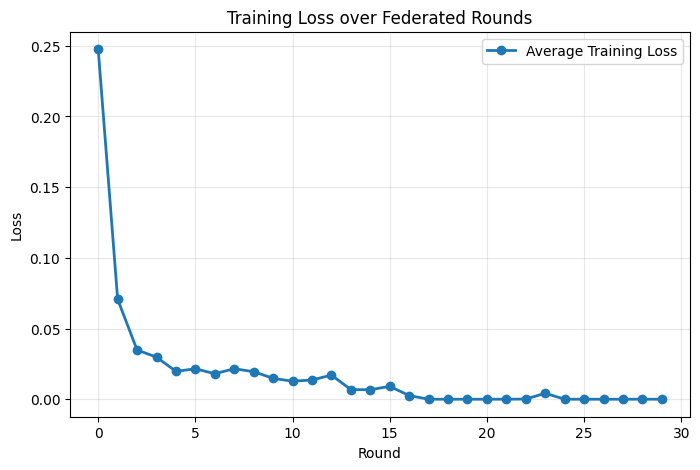

In [18]:
print("\n=== Final Evaluation ===")

global_acc = evaluate_model(global_model, global_test_loader)
print(f"Global Accuracy: {global_acc:.4f}")

local_accs = []
for cid in range(CONFIG['num_clients']):
    local_acc = evaluate_model(global_model, client_test_loaders[cid])
    local_accs.append(local_acc)
    print(f"Client {cid+1} ({CONFIG['class_names'][cid]}) Local Accuracy: {local_acc:.4f}")

print(f"\nAverage Local Accuracy: {np.mean(local_accs):.4f}")

# Plot Training Loss
plt.figure(figsize=(8, 5))
plt.plot(training_losses, marker='o', linewidth=2, label='Average Training Loss')
plt.title('Training Loss over Federated Rounds')
plt.xlabel('Round')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [19]:
print("=" * 60)
print("PHASE 3: Dual-Module Personalized Accuracy (K-step Local Fine-Tuning)")
print("=" * 60)

def evaluate_personalized(client_model, train_loader, test_loader, device, k_steps=10):
    """
    Take the specific client's dual-module model (Global + Private Identity),
    fine-tune for K steps on their local data, and update the LTH mask one final time.
    """
    # 1. We copy the specific client's model, NOT the generic global model
    local_model = deepcopy(client_model).to(device)
    optimizer = AdamW(local_model.parameters(), lr=CONFIG['lr'])

    local_model.train()
    steps = 0
    for batch in train_loader:
        if steps >= k_steps:
            break
        batch = {k: v.to(device) for k, v in batch.items()}
        loss = local_model(**batch).loss
        
        optimizer.zero_grad()
        loss.backward()
        clip_grad_norm_(local_model.parameters(), max_norm=1.0)
        optimizer.step()
        steps += 1

    # 2. NEW: Enforce the Lottery Ticket sparsity one last time 
    # so the private identity absorbs the fine-tuning!
    for module in local_model.modules():
        if hasattr(module, 'update_private_mask'):
            module.update_private_mask()

    # 3. Evaluate the fully fine-tuned, dynamically masked model
    acc = evaluate_model(local_model, test_loader)
    del local_model
    torch.cuda.empty_cache()
    return acc


personalized_accs = []
for cid in range(CONFIG['num_clients']):
    
    # NEW: Pass client_models[cid] instead of global_model
    p_acc = evaluate_personalized(
        client_models[cid], 
        client_train_loaders[cid],
        client_test_loaders[cid],
        device,
        k_steps=CONFIG['personalization_steps']
    )
    
    personalized_accs.append(p_acc)
    print(f"  Client {cid+1} ({CONFIG['class_names'][cid]}) Personalized Acc: {p_acc:.4f}")

print(f"\nAverage Personalized Accuracy: {np.mean(personalized_accs):.4f}")

PHASE 3: Dual-Module Personalized Accuracy (K-step Local Fine-Tuning)
  Client 1 (World) Personalized Acc: 0.9178
  Client 2 (Sports) Personalized Acc: 0.9499
  Client 3 (Business) Personalized Acc: 0.9098
  Client 4 (Sci/Tech) Personalized Acc: 0.9138

Average Personalized Accuracy: 0.9228


### Section 4: Visualisations

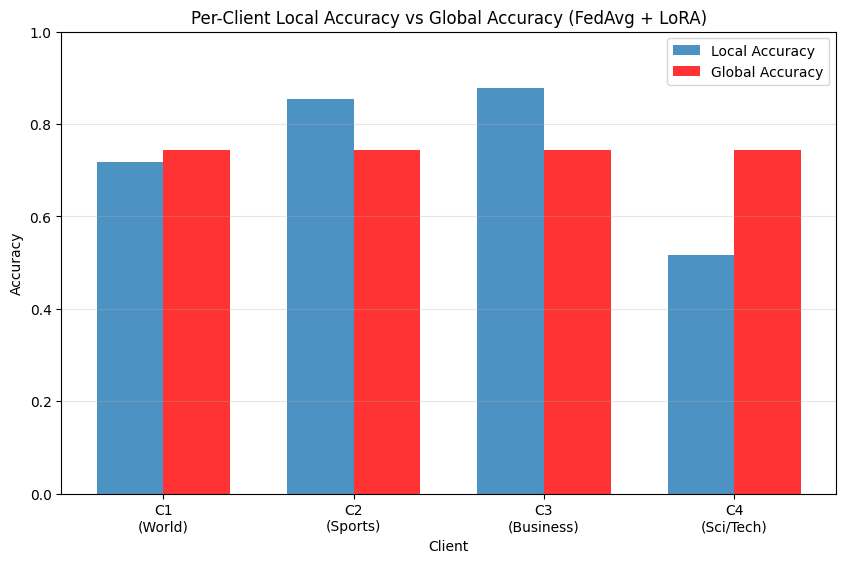

In [20]:
plt.figure(figsize=(10, 6))
x = np.arange(CONFIG['num_clients'])
width = 0.35

plt.bar(x - width/2, local_accs, width, label='Local Accuracy', alpha=0.8)
plt.bar(x + width/2, [global_acc]*CONFIG['num_clients'], width, label='Global Accuracy', alpha=0.8, color='red')

plt.xlabel('Client')
plt.ylabel('Accuracy')
plt.title('Per-Client Local Accuracy vs Global Accuracy (FedAvg + LoRA)')
plt.xticks(x, [f"C{i+1}\n({CONFIG['class_names'][i]})" for i in range(CONFIG['num_clients'])])
plt.legend()
plt.ylim(0, 1.0)
plt.grid(axis='y', alpha=0.3)
plt.show()

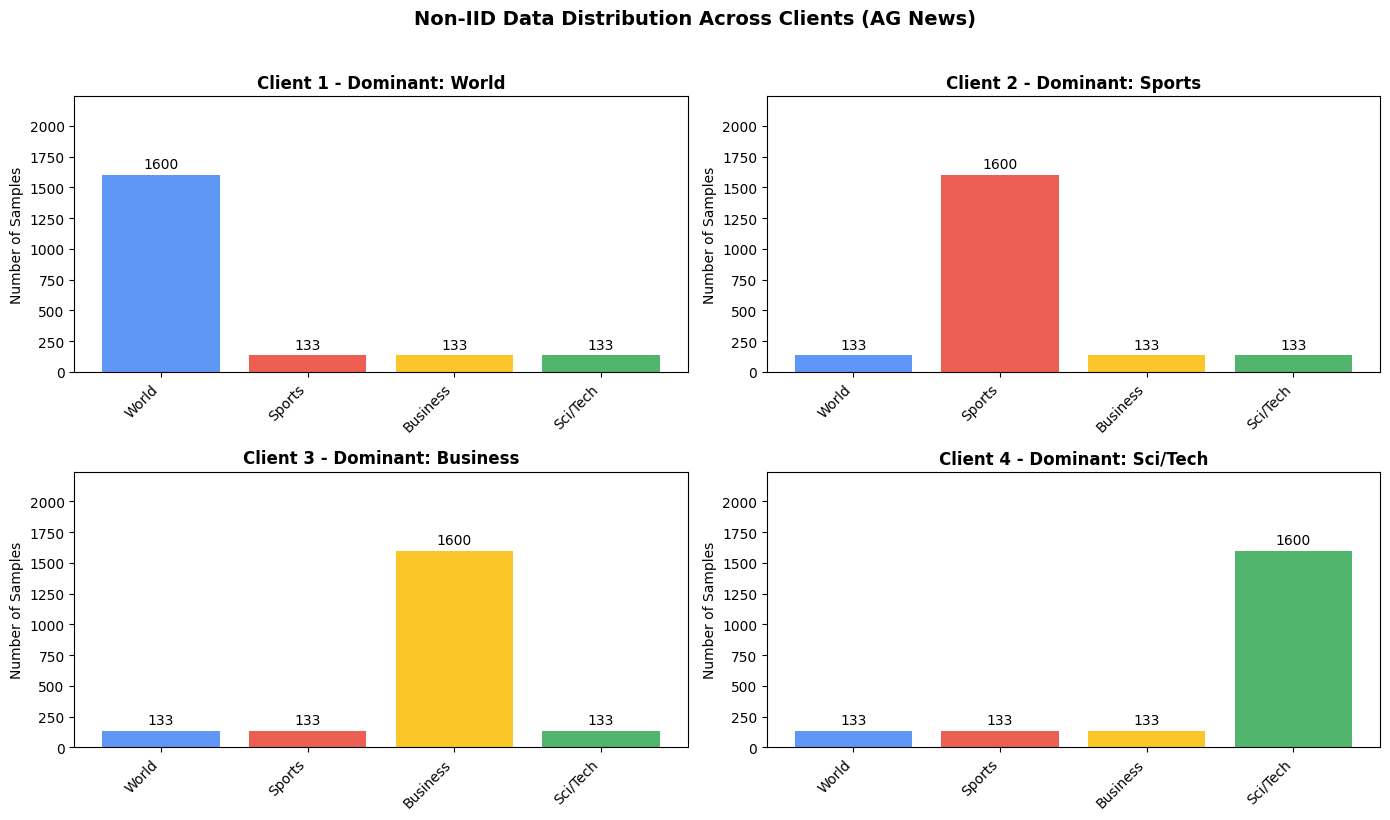

In [21]:
# === Client-wise Class Distribution ===
plt.figure(figsize=(14, 8))
colors = ['#4285F4', '#EA4335', '#FBBC05', '#34A853']

for i in range(CONFIG['num_clients']):
    lbs = np.array(tokenized['train']['labels'])[train_idx[i]]
    counts = [np.sum(lbs == c) for c in range(4)]
    
    plt.subplot(2, 2, i+1)
    bars = plt.bar(CONFIG['class_names'], counts, color=colors, alpha=0.85)
    plt.title(f"Client {i+1} - Dominant: {CONFIG['class_names'][i]}", 
              fontsize=12, fontweight='bold')
    plt.ylabel("Number of Samples")
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, CONFIG['n_train'] * 1.12)
    
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 30,
                 f'{int(height)}', ha='center', va='bottom', fontsize=10)

plt.suptitle("Non-IID Data Distribution Across Clients (AG News)", 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [22]:
# === Communication Cost Analysis ===
def count_lora_parameters(model):
    count = 0
    for name, param in model.named_parameters():
        if "lora_" in name and param.requires_grad:
            count += param.numel()
    return count

lora_params = count_lora_parameters(global_model)
bytes_per_client = lora_params * 4   # float32 = 4 bytes
total_bytes_per_round = bytes_per_client * CONFIG['num_clients']

print("\n=== Communication Cost (FedAvg + LoRA) ===")
print(f"LoRA parameters per client: {lora_params:,}")
print(f"Bytes sent per client per round: {bytes_per_client:,} bytes")
print(f"Total bytes per round ({CONFIG['num_clients']} clients): {total_bytes_per_round:,} bytes")
print(f"Approximate MB per round: {total_bytes_per_round / (1024*1024):.2f} MB")


=== Communication Cost (FedAvg + LoRA) ===
LoRA parameters per client: 294,912
Bytes sent per client per round: 1,179,648 bytes
Total bytes per round (4 clients): 4,718,592 bytes
Approximate MB per round: 4.50 MB


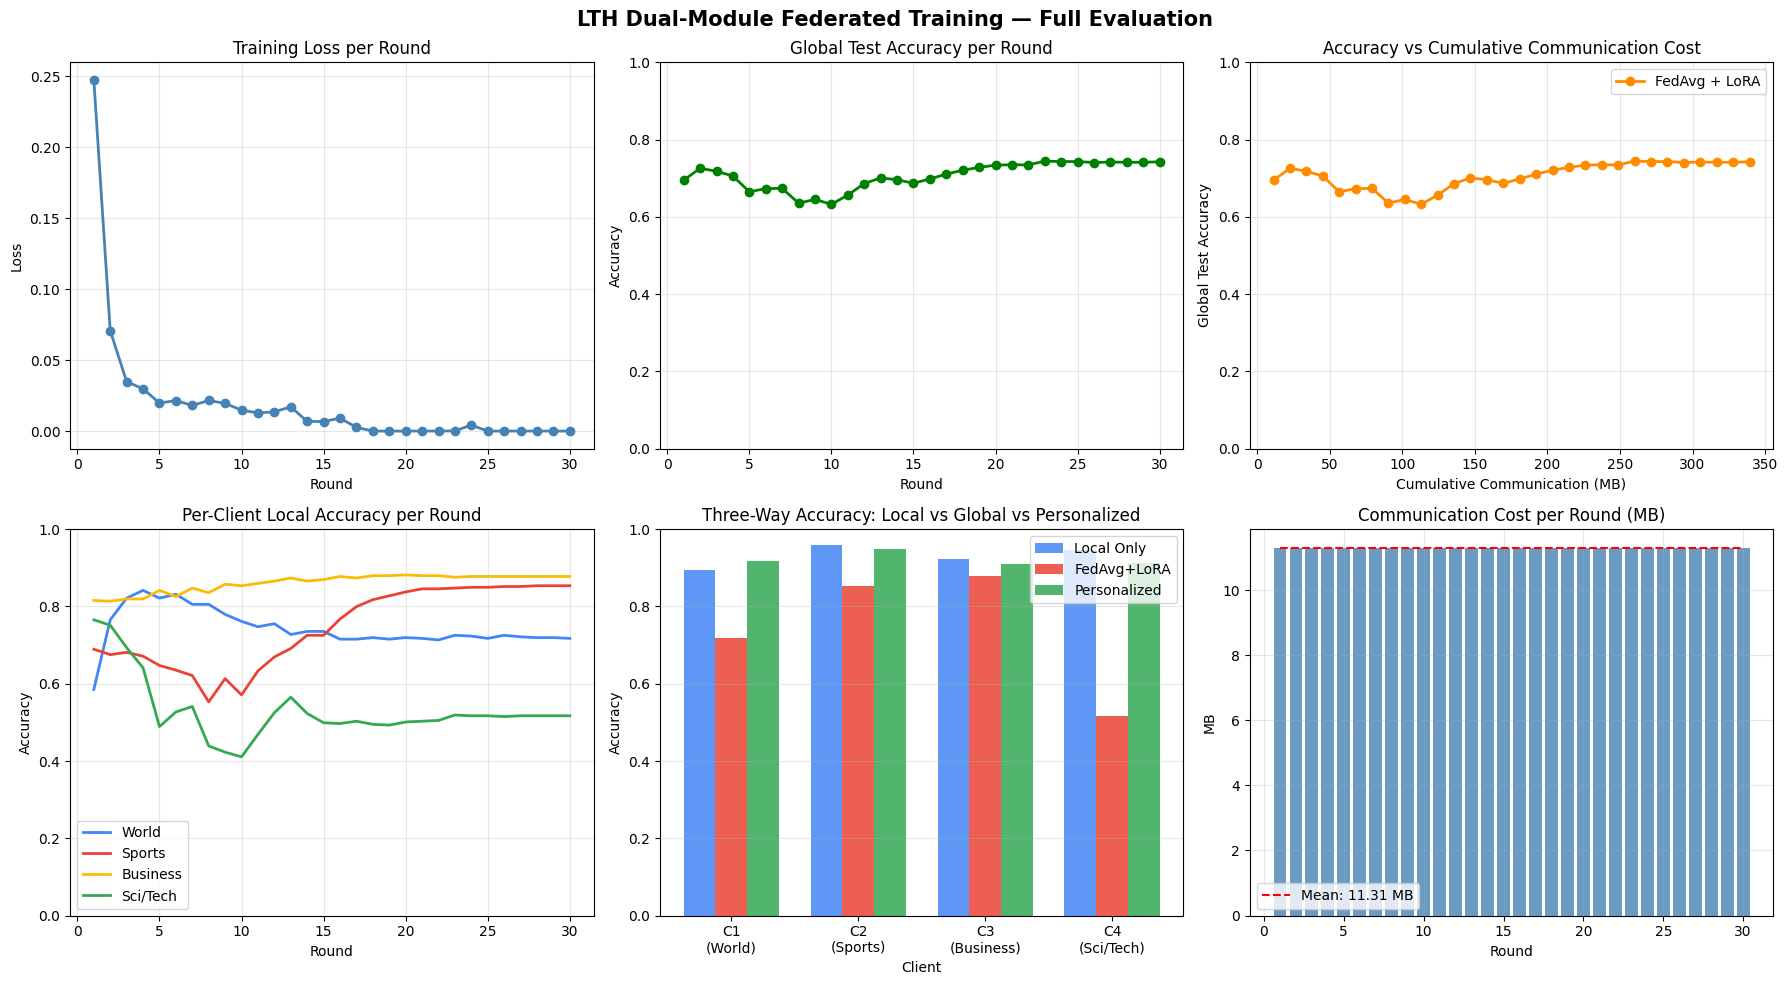

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('LTH Dual-Module Federated Training — Full Evaluation', fontsize=15, fontweight='bold')

rounds = list(range(1, CONFIG['num_rounds'] + 1))

# --- Plot 1: Training Loss ---
axes[0, 0].plot(rounds, training_losses, marker='o', linewidth=2, color='steelblue')
axes[0, 0].set_title('Training Loss per Round')
axes[0, 0].set_xlabel('Round')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].grid(True, alpha=0.3)

# --- Plot 2: Global Accuracy per Round ---
axes[0, 1].plot(rounds, round_global_accs, marker='o', linewidth=2, color='green')
axes[0, 1].set_title('Global Test Accuracy per Round')
axes[0, 1].set_xlabel('Round')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_ylim(0, 1.0)
axes[0, 1].grid(True, alpha=0.3)

# --- Plot 3: Accuracy vs Cumulative Communication Cost ---
# THIS is the standard FL efficiency plot
axes[0, 2].plot(
    cumulative_comm_mb[1:],  # skip the 0 at index 0
    round_global_accs,
    marker='o', linewidth=2, color='darkorange', label='FedAvg + LoRA'
)
axes[0, 2].set_title('Accuracy vs Cumulative Communication Cost')
axes[0, 2].set_xlabel('Cumulative Communication (MB)')
axes[0, 2].set_ylabel('Global Test Accuracy')
axes[0, 2].set_ylim(0, 1.0)
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# --- Plot 4: Per-Client Accuracy per Round ---
colors = ['#4285F4', '#EA4335', '#FBBC05', '#34A853']
for cid in range(CONFIG['num_clients']):
    axes[1, 0].plot(rounds, round_local_accs[cid],
                    label=CONFIG['class_names'][cid],
                    color=colors[cid], linewidth=2)
axes[1, 0].set_title('Per-Client Local Accuracy per Round')
axes[1, 0].set_xlabel('Round')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_ylim(0, 1.0)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# --- Plot 5: Three-way Accuracy Comparison ---
global_accs_final  = [round_local_accs[cid][-1] for cid in range(CONFIG['num_clients'])]
x = np.arange(CONFIG['num_clients'])
width = 0.25

axes[1, 1].bar(x - width, local_only_accs,       width, label='Local Only',     alpha=0.85, color='#4285F4')
axes[1, 1].bar(x,          global_accs_final,     width, label='FedAvg+LoRA',    alpha=0.85, color='#EA4335')
axes[1, 1].bar(x + width,  personalized_accs,     width, label='Personalized',   alpha=0.85, color='#34A853')
axes[1, 1].set_title('Three-Way Accuracy: Local vs Global vs Personalized')
axes[1, 1].set_xlabel('Client')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels([f"C{i+1}\n({CONFIG['class_names'][i]})" for i in range(CONFIG['num_clients'])])
axes[1, 1].set_ylim(0, 1.0)
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.3)

# --- Plot 6: Communication Cost per Round ---
axes[1, 2].bar(rounds, round_comm_cost_mb, color='steelblue', alpha=0.8)
axes[1, 2].plot(rounds, [np.mean(round_comm_cost_mb)] * len(rounds),
                'r--', label=f'Mean: {np.mean(round_comm_cost_mb):.2f} MB')
axes[1, 2].set_title('Communication Cost per Round (MB)')
axes[1, 2].set_xlabel('Round')
axes[1, 2].set_ylabel('MB')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
print("\n" + "=" * 65)
print("FINAL SUMMARY TABLE")
print("=" * 65)
print(f"{'Client':<12} {'Local-Only':>12} {'LTH - Dual Adapter':>13} {'Personalized':>14}")
print("-" * 65)
for cid in range(CONFIG['num_clients']):
    name   = CONFIG['class_names'][cid]
    lo     = local_only_accs[cid]
    fed    = round_local_accs[cid][-1]
    pers   = personalized_accs[cid]
    print(f"C{cid+1} {name:<10} {lo:>12.4f} {fed:>13.4f} {pers:>14.4f}")
print("-" * 65)
print(f"{'Average':<12} {np.mean(local_only_accs):>12.4f} {np.mean(global_accs_final):>13.4f} {np.mean(personalized_accs):>14.4f}")

lora_params = count_lora_parameters(global_model)
total_comm  = cumulative_comm_mb[-1]
print(f"\nLoRA params per client : {lora_params:,}")
print(f"Total communication    : {total_comm:.2f} MB over {CONFIG['num_rounds']} rounds")
print(f"Avg per round          : {np.mean(round_comm_cost_mb):.2f} MB")
print(f"Baseline sparsity      : 0.00% (all LoRA params uploaded)")
print("=" * 65)


FINAL SUMMARY TABLE
Client         Local-Only LTH - Dual Adapter   Personalized
-----------------------------------------------------------------
C1 World            0.8938        0.7174         0.9178
C2 Sports           0.9599        0.8537         0.9499
C3 Business         0.9218        0.8778         0.9098
C4 Sci/Tech         0.9459        0.5170         0.9138
-----------------------------------------------------------------
Average            0.9304        0.7415         0.9228

LoRA params per client : 294,912
Total communication    : 339.26 MB over 30 rounds
Avg per round          : 11.31 MB
Baseline sparsity      : 0.00% (all LoRA params uploaded)


In [25]:
print("\n=== Global Balanced Test Accuracy ===")
local_only_global  = []
fedavg_global      = evaluate_model(global_model, global_test_loader)

for cid in range(CONFIG['num_clients']):
    # Re-evaluate local-only models on global test
    # (you need to save them during Phase 1, or re-train briefly)
    pass

print(f"FedAvg+LoRA Global Acc : {fedavg_global:.4f}")


=== Global Balanced Test Accuracy ===
FedAvg+LoRA Global Acc : 0.7425
